In [22]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

from config import (
    CONTENT_SCALE,
    DRAWING_BBOX,
    TEMPLATES_DIR, OUTPUT_DIR,
)
from utils import transfer_color, image_rect_from_svg

# --- что обрабатываем ---
CHAR_ID = "002"
STEM = "002_test2"

# --- derived ---
CHAR_DIR = TEMPLATES_DIR / CHAR_ID
CORRECTED_PATH = OUTPUT_DIR / f"stage3_corrected_{STEM}.png"
SVG_PATH = CHAR_DIR / "mask.svg"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Color Transfer

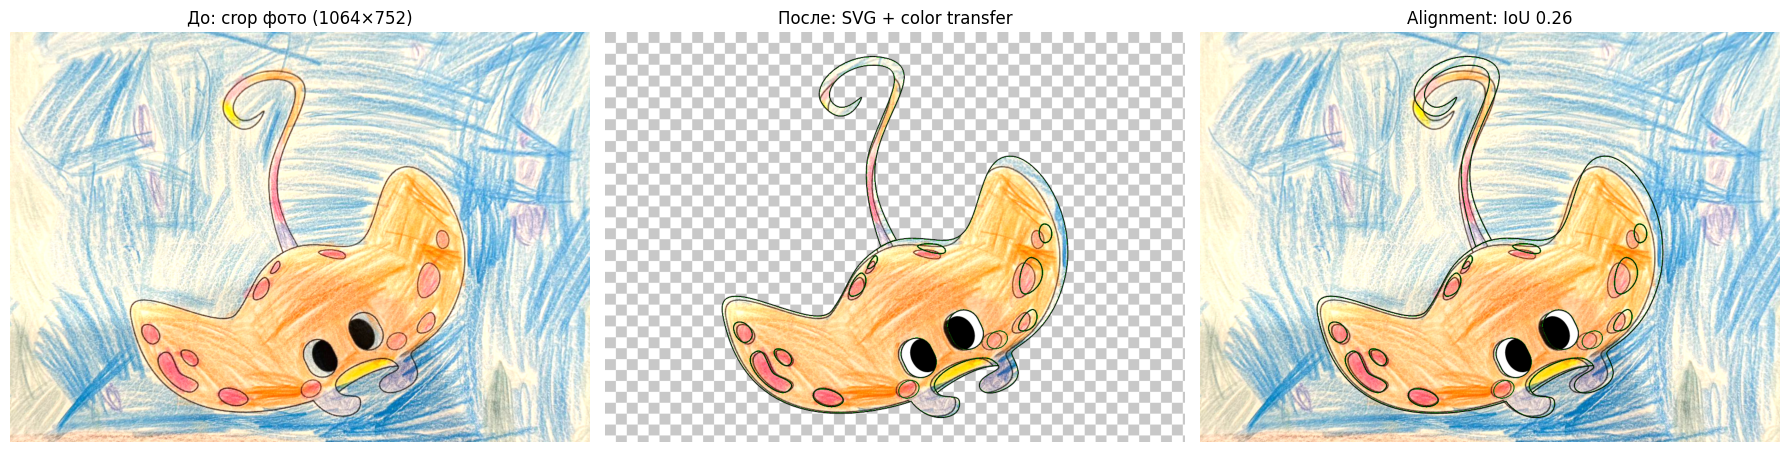

In [23]:
from svg import SvgCharacter

corrected = cv2.imread(str(CORRECTED_PATH))
image_rect = image_rect_from_svg(str(SVG_PATH), CONTENT_SCALE)
ix, iy, iw, ih = image_rect

result = transfer_color(corrected, str(SVG_PATH), image_rect)
rgba = result["rgba"]

def make_checker(h, w, block=20):
    ch = np.zeros((h, w, 3), dtype=np.uint8)
    for y in range(0, h, block):
        for x in range(0, w, block):
            ch[y:y+block, x:x+block] = 200 if (y // block + x // block) % 2 == 0 else 255
    return ch

photo_crop = corrected[iy : iy + ih, ix : ix + iw]
checker = make_checker(ih, iw)
alpha = rgba[..., 3:4] / 255.0
digital_vis = (rgba[..., :3] * alpha + checker * (1 - alpha)).astype(np.uint8)

# --- IoU: насколько "раскрашенная область" совпадает с SVG-маской ---
svg_full = SvgCharacter(str(SVG_PATH)).render(iw, ih, fill_zones="white")
svg_contour = SvgCharacter(str(SVG_PATH)).render(iw, ih, fill_zones="transparent")

char_mask = cv2.cvtColor(photo_crop, cv2.COLOR_BGR2GRAY) < 230   # для color transfer — non-white на фото
svg_mask = svg_full[..., 3] > 10
iou = (char_mask & svg_mask).sum() / max((char_mask | svg_mask).sum(), 1)

# Overlay: SVG-контур поверх фото
svg_a = svg_contour[..., 3:4] / 255.0
overlay = (svg_contour[..., :3] * svg_a + photo_crop * (1 - svg_a)).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(photo_crop, cv2.COLOR_BGR2RGB))
axes[0].axis("off"); axes[0].set_title(f"До: crop фото ({iw}×{ih})")
axes[1].imshow(cv2.cvtColor(digital_vis, cv2.COLOR_BGR2RGB))
axes[1].axis("off"); axes[1].set_title("После: SVG + color transfer")
axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[2].axis("off"); axes[2].set_title(f"Alignment: IoU {iou:.2f}")
plt.tight_layout(); plt.show()

In [24]:
out_path = OUTPUT_DIR / f"stage4_svg_{STEM}.png"
cv2.imwrite(str(out_path), rgba)
print(f"Сохранено: {out_path}")

Сохранено: C:\Users\Luga\Documents\GitHub\ink-to-motion\dev\pipeline\output\stage4_svg_002_test2.png


# Segmentation Only

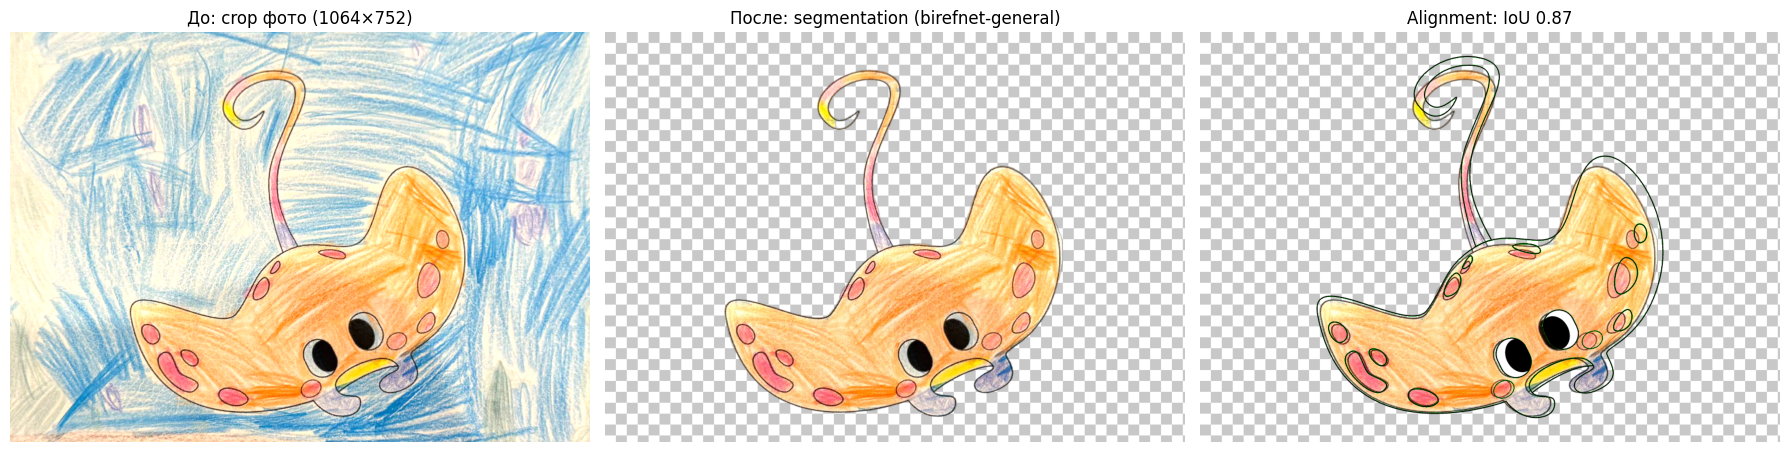

In [25]:
from rembg import new_session, remove

MODEL = "birefnet-general"
session = new_session(MODEL)

# Обрезаем ДО сегментации — модель видит только персонажа, без маркеров/декора/шума
ix, iy, iw, ih = image_rect
photo_crop = corrected[iy : iy + ih, ix : ix + iw]

# rembg работает с bytes — кодируем crop в PNG
_, img_bytes = cv2.imencode(".png", photo_crop)
fg_png = remove(img_bytes.tobytes(), session=session)
fg_crop = cv2.imdecode(np.frombuffer(fg_png, np.uint8), cv2.IMREAD_UNCHANGED)  # BGRA 1163×711

checker = make_checker(ih, iw)
alpha = fg_crop[..., 3:4] / 255.0
seg_vis = (fg_crop[..., :3] * alpha + checker * (1 - alpha)).astype(np.uint8)

# --- IoU: насколько маска сегментации совпадает с SVG ---
svg_full = SvgCharacter(str(SVG_PATH)).render(iw, ih, fill_zones="white")
svg_contour = SvgCharacter(str(SVG_PATH)).render(iw, ih, fill_zones="transparent")

char_mask = fg_crop[..., 3] > 10              # для сегментации — альфа от модели
svg_mask = svg_full[..., 3] > 10
iou = (char_mask & svg_mask).sum() / max((char_mask | svg_mask).sum(), 1)

# Overlay: SVG-контур поверх seg_vis
svg_a = svg_contour[..., 3:4] / 255.0
overlay = (svg_contour[..., :3] * svg_a + seg_vis * (1 - svg_a)).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(photo_crop, cv2.COLOR_BGR2RGB))
axes[0].axis("off"); axes[0].set_title(f"До: crop фото ({iw}×{ih})")
axes[1].imshow(cv2.cvtColor(seg_vis, cv2.COLOR_BGR2RGB))
axes[1].axis("off"); axes[1].set_title(f"После: segmentation ({MODEL})")
axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[2].axis("off"); axes[2].set_title(f"Alignment: IoU {iou:.2f}")
plt.tight_layout(); plt.show()

In [26]:
out_path = OUTPUT_DIR / f"stage4_seg-{MODEL}_{STEM}.png"
cv2.imwrite(str(out_path), fg_crop)
print(f"Сохранено: {out_path}")

Сохранено: C:\Users\Luga\Documents\GitHub\ink-to-motion\dev\pipeline\output\stage4_seg-birefnet-general_002_test2.png


In [27]:
align_out = OUTPUT_DIR / f"stage4_seg-{MODEL}_{STEM}_align-iou{iou:.2f}.png"
cv2.imwrite(str(align_out), overlay)
print(f"Сохранено: {align_out}")

Сохранено: C:\Users\Luga\Documents\GitHub\ink-to-motion\dev\pipeline\output\stage4_seg-birefnet-general_002_test2_align-iou0.87.png


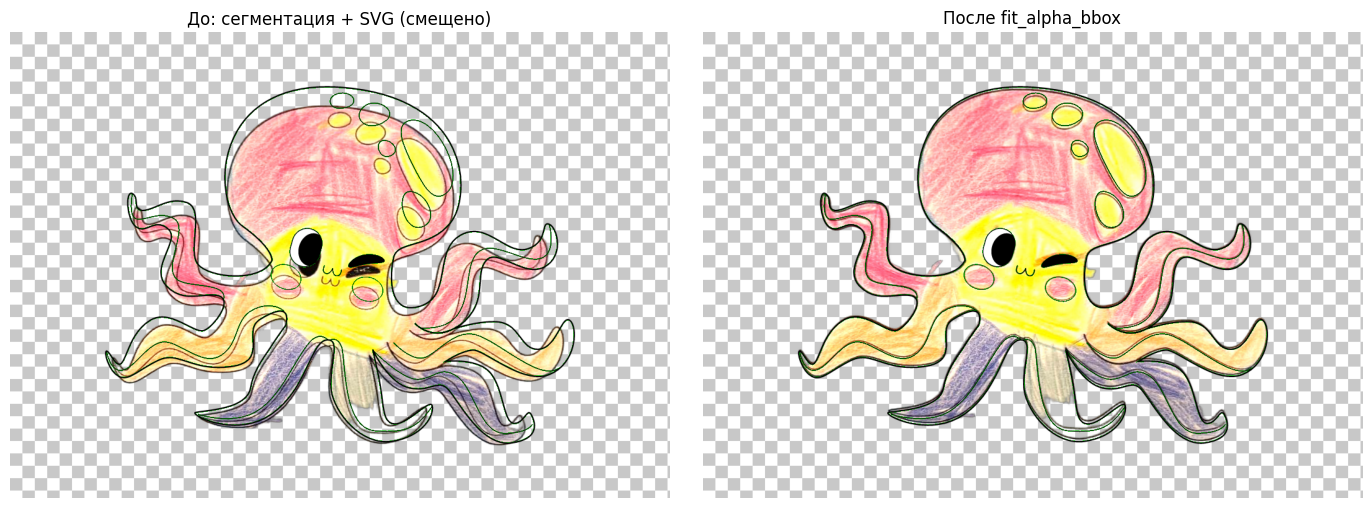

In [ ]:
def fit_alpha_bbox(src_rgba, dst_rgba):
    """Масштабирует и сдвигает src так, чтобы alpha-bbox совпал с dst."""
    def bbox(rgba):
        a = rgba[..., 3]
        ys, xs = np.where(a > 10)
        if len(xs) == 0:
            return None
        return (float(xs.min()), float(ys.min()),
                float(xs.max() + 1 - xs.min()), float(ys.max() + 1 - ys.min()))

    sb, db = bbox(src_rgba), bbox(dst_rgba)
    if sb is None or db is None:
        return src_rgba

    sx, sy, sw, sh = sb
    dx, dy, dw, dh = db
    scale = min(dw / sw, dh / sh)    # пропорциональный scale (без деформации)

    # Центр src после scale должен совпасть с центром dst bbox
    tx = (dx + dw / 2) - (sx + sw / 2) * scale
    ty = (dy + dh / 2) - (sy + sh / 2) * scale

    M = np.array([[scale, 0, tx], [0, scale, ty]], dtype=np.float32)
    h, w = dst_rgba.shape[:2]
    return cv2.warpAffine(src_rgba, M, (w, h),
                          flags=cv2.INTER_LANCZOS4,
                          borderMode=cv2.BORDER_CONSTANT,
                          borderValue=(0, 0, 0, 0))


# SVG-контур как reference для bbox
svg_contour = SvgCharacter(str(SVG_PATH)).render(iw, ih, fill_zones="transparent")

# Подгоняем сегментацию под bbox контура
fg_aligned = fit_alpha_bbox(fg_crop, svg_contour)

# --- Визуал: до vs после подгонки ---
def overlay_contour(seg_rgba, svg_rgba):
    ck = make_checker(*seg_rgba.shape[:2])
    a = seg_rgba[..., 3:4] / 255.0
    seg_on_ck = (seg_rgba[..., :3] * a + ck * (1 - a)).astype(np.uint8)
    sa = svg_rgba[..., 3:4] / 255.0
    return (svg_rgba[..., :3] * sa + seg_on_ck * (1 - sa)).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(overlay_contour(fg_crop, svg_contour), cv2.COLOR_BGR2RGB))
axes[0].axis("off"); axes[0].set_title("До: сегментация + SVG (смещено)")
axes[1].imshow(cv2.cvtColor(overlay_contour(fg_aligned, svg_contour), cv2.COLOR_BGR2RGB))
axes[1].axis("off"); axes[1].set_title("После fit_alpha_bbox")
plt.tight_layout(); plt.show()

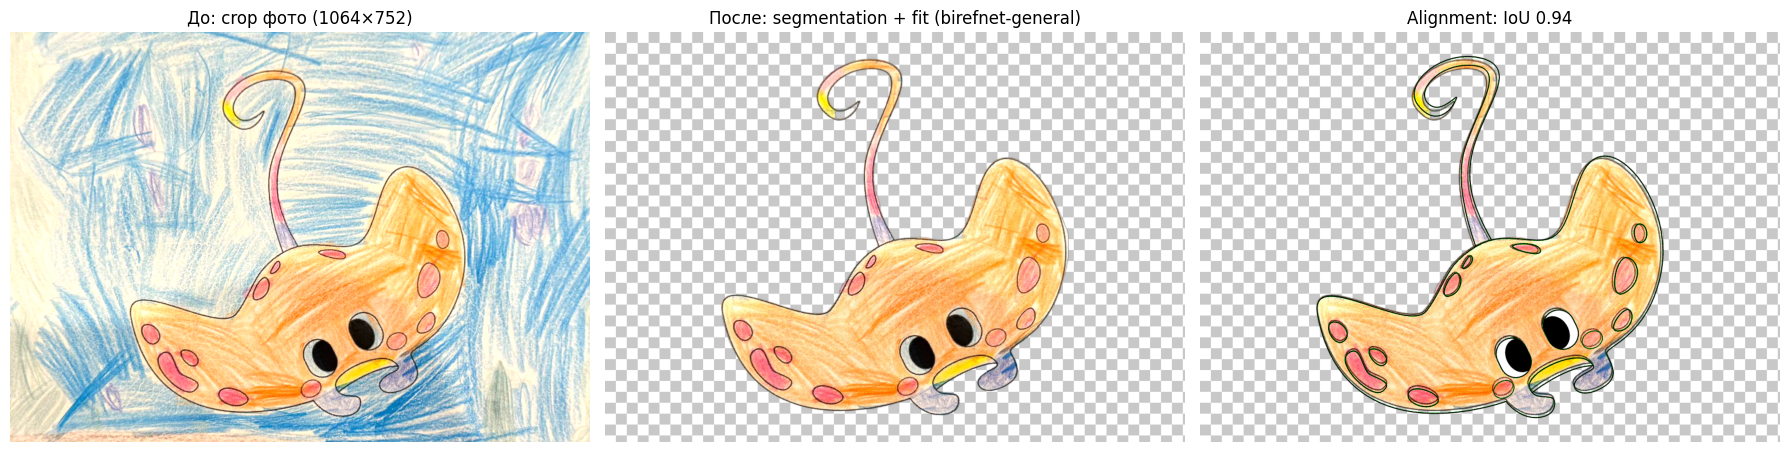

In [28]:
from rembg import new_session, remove

MODEL = "birefnet-general"
session = new_session(MODEL)

# Crop ДО сегментации — модель видит только персонажа
ix, iy, iw, ih = image_rect
photo_crop = corrected[iy : iy + ih, ix : ix + iw]

# Сегментация
_, img_bytes = cv2.imencode(".png", photo_crop)
fg_png = remove(img_bytes.tobytes(), session=session)
fg_raw = cv2.imdecode(np.frombuffer(fg_png, np.uint8), cv2.IMREAD_UNCHANGED)  # BGRA

# Подгоняем под SVG (центр + scale)
svg_contour = SvgCharacter(str(SVG_PATH)).render(iw, ih, fill_zones="transparent")
svg_full = SvgCharacter(str(SVG_PATH)).render(iw, ih, fill_zones="white")
fg_aligned = fit_alpha_bbox(fg_raw, svg_contour)

# Визуал результата на шахматке
checker = make_checker(ih, iw)
alpha = fg_aligned[..., 3:4] / 255.0
seg_vis = (fg_aligned[..., :3] * alpha + checker * (1 - alpha)).astype(np.uint8)

# IoU
char_mask = fg_aligned[..., 3] > 10
svg_mask = svg_full[..., 3] > 10
iou = (char_mask & svg_mask).sum() / max((char_mask | svg_mask).sum(), 1)

# Overlay для 3-й колонки
svg_a = svg_contour[..., 3:4] / 255.0
overlay = (svg_contour[..., :3] * svg_a + seg_vis * (1 - svg_a)).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(photo_crop, cv2.COLOR_BGR2RGB))
axes[0].axis("off"); axes[0].set_title(f"До: crop фото ({iw}×{ih})")
axes[1].imshow(cv2.cvtColor(seg_vis, cv2.COLOR_BGR2RGB))
axes[1].axis("off"); axes[1].set_title(f"После: segmentation + fit ({MODEL})")
axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[2].axis("off"); axes[2].set_title(f"Alignment: IoU {iou:.2f}")
plt.tight_layout(); plt.show()